Preprocessing Complete. Input features: 4 -> ['Radiation', 'Time_Sin', 'Time_Cos', 'Cum_Radiation']

--- Starting Enhanced Training Loop ---
Epoch  100/3000, Train Loss: 0.001571, Val Loss: 0.000737
Epoch  200/3000, Train Loss: 0.000737, Val Loss: 0.001373
Epoch  300/3000, Train Loss: 0.000704, Val Loss: 0.000464
Epoch  400/3000, Train Loss: 0.000392, Val Loss: 0.000465
Epoch  500/3000, Train Loss: 0.000517, Val Loss: 0.000337
Epoch  600/3000, Train Loss: 0.000363, Val Loss: 0.000514
Epoch  700/3000, Train Loss: 0.000371, Val Loss: 0.000320
Epoch  800/3000, Train Loss: 0.000411, Val Loss: 0.000495
Epoch  900/3000, Train Loss: 0.000194, Val Loss: 0.000300
Epoch 1000/3000, Train Loss: 0.000161, Val Loss: 0.000452
Epoch 1100/3000, Train Loss: 0.000402, Val Loss: 0.000551
Epoch 1200/3000, Train Loss: 0.000188, Val Loss: 0.000231
Epoch 1300/3000, Train Loss: 0.000139, Val Loss: 0.000319
Epoch 1400/3000, Train Loss: 0.000152, Val Loss: 0.000315
Epoch 1500/3000, Train Loss: 0.000168, Val Loss

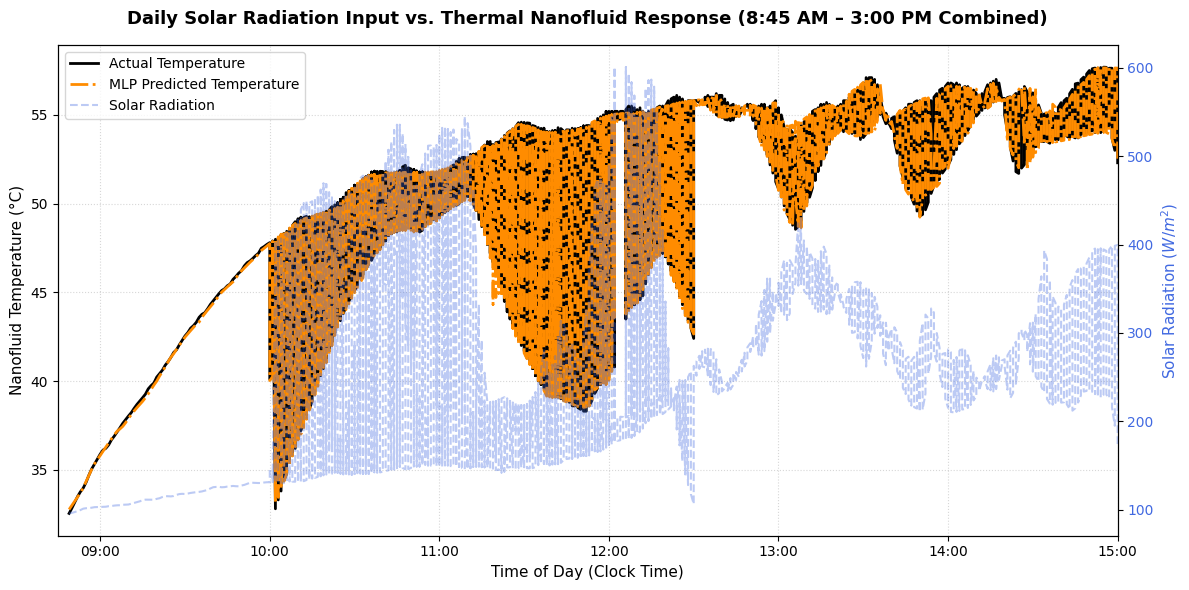

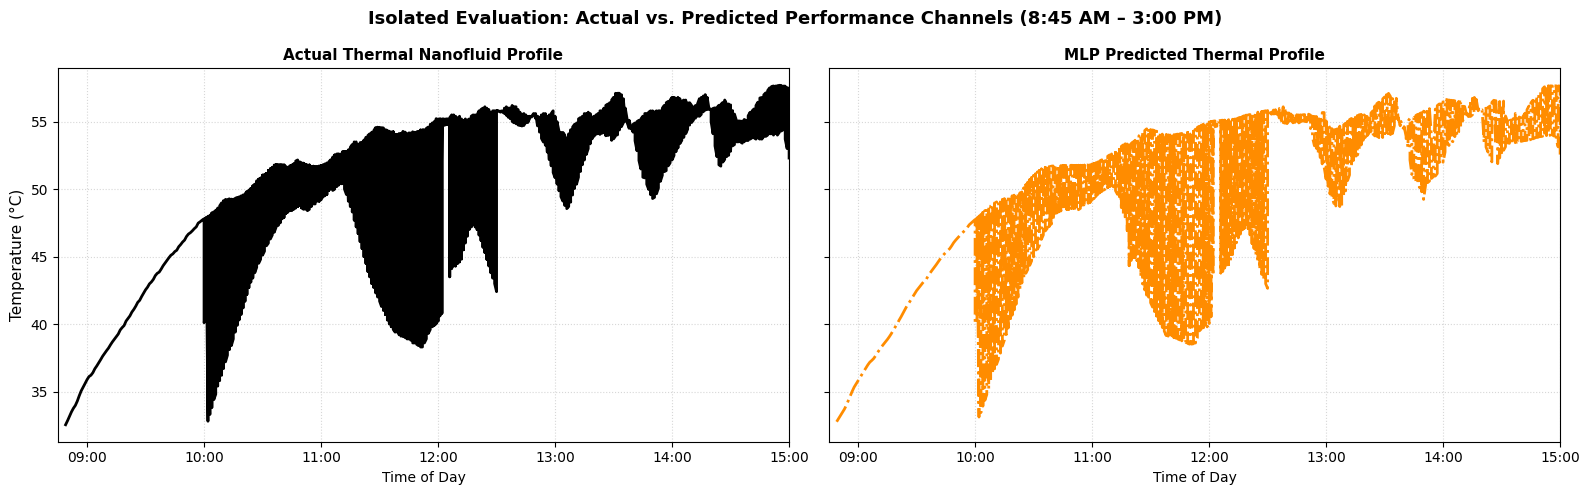

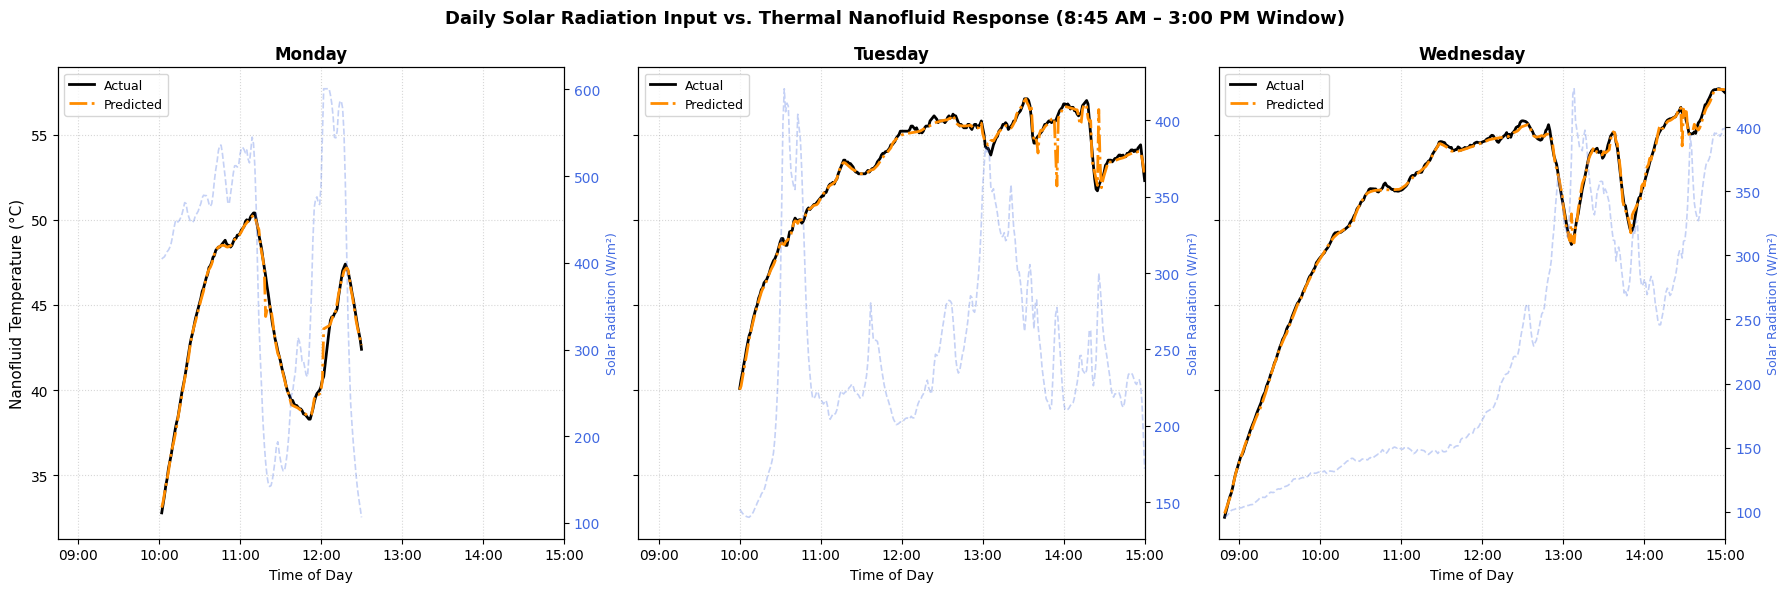

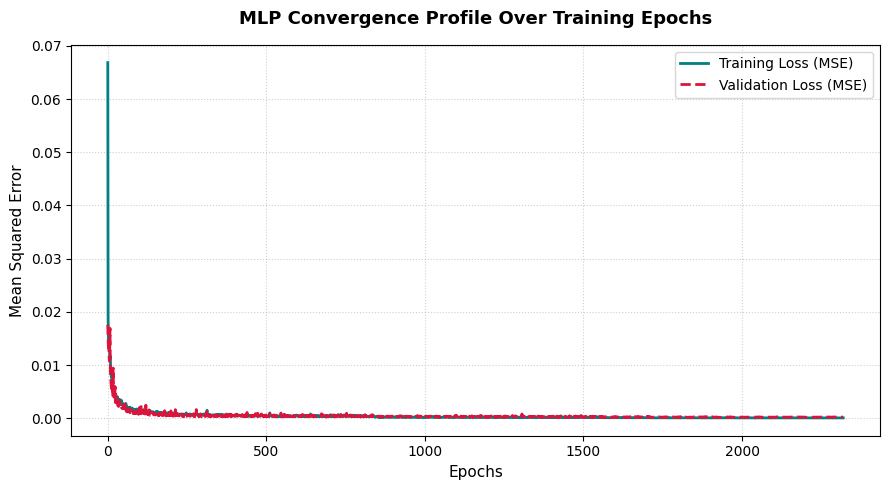

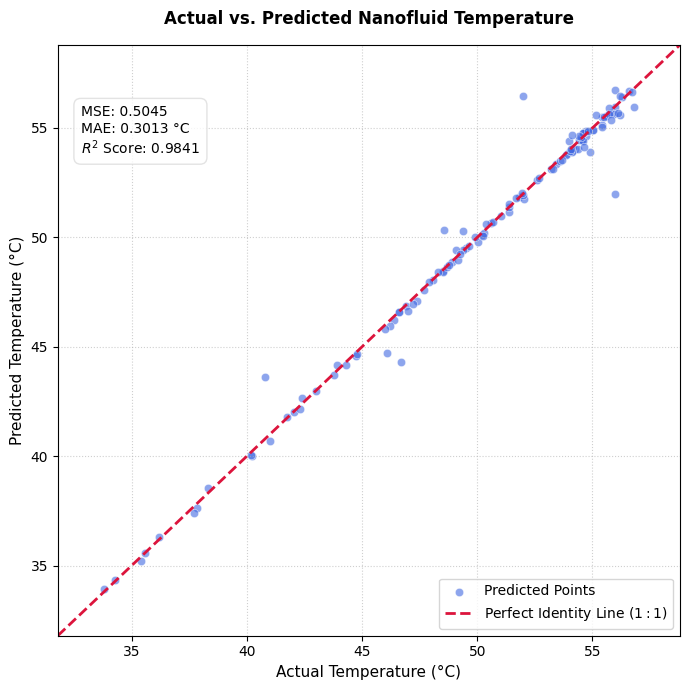

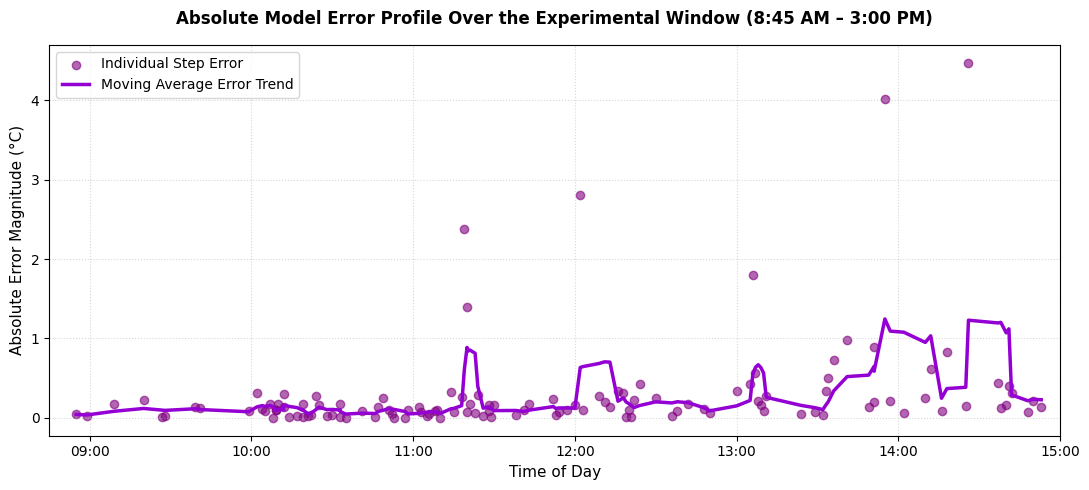

In [12]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
 
# ==========================================
# 2. Data Loading & Per-Day Offset Assignment
# ==========================================
DAY_OFFSETS = {
    'MONDAY':    10 * 60,        # 600 min
    'TUESDAY':   10 * 60,        # 600 min
    'WEDNESDAY':  8 * 60 + 45,   # 525 min
}
 
df_raw = pd.read_csv('datasets/COMBINED DATASET - Sheet1.csv', skiprows=1)
df_raw.columns = df_raw.columns.str.strip()
 
current_day = 'MONDAY'
day_labels  = []
 
day_col = df_raw.iloc[:, 6].astype(str).str.strip().str.upper()
 
for val in day_col:
    if val in DAY_OFFSETS:
        current_day = val
    day_labels.append(current_day)
 
df_raw['Day'] = day_labels
 
df_clean = pd.DataFrame()
df_clean['Time_Min']    = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
df_clean['Radiation']   = pd.to_numeric(df_raw['2  Pyra02_B [W/m2]'], errors='coerce')
df_clean['Temperature'] = pd.to_numeric(df_raw['AuNF-Tarap'], errors='coerce')
df_clean['Day']         = df_raw['Day'].values
 
df_clean = df_clean.dropna(subset=['Time_Min', 'Radiation', 'Temperature']).reset_index(drop=True)
df_clean['Time_Min_Abs'] = df_clean['Time_Min'] + df_clean['Day'].map(DAY_OFFSETS)
 
for col in ['Radiation', 'Temperature']:
    u, s = df_clean[col].mean(), df_clean[col].std()
    df_clean = df_clean[(df_clean[col] > u - 3*s) & (df_clean[col] < u + 3*s)]
 
df_clean = df_clean.reset_index(drop=True)
 
# ==========================================
# 3. Physics-Informed Feature Engineering
# ==========================================
df_clean['Time_Sin'] = np.sin(2 * np.pi * df_clean['Time_Min_Abs'] / 1440.0)
df_clean['Time_Cos'] = np.cos(2 * np.pi * df_clean['Time_Min_Abs'] / 1440.0)
 
df_clean['Cum_Radiation'] = (
    df_clean.groupby('Day')['Radiation']
    .cumsum()
)
 
X_cols = ['Radiation', 'Time_Sin', 'Time_Cos', 'Cum_Radiation']
X_raw  = df_clean[X_cols].values
y_raw  = df_clean[['Temperature']].values
 
scaler_x = MinMaxScaler(feature_range=(0.1, 0.9))
scaler_y = MinMaxScaler(feature_range=(0.1, 0.9))
 
X_scaled = scaler_x.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)
 
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=42)
X_val,   X_test,  y_val,   y_test  = train_test_split(X_temp,  y_temp,  test_size=0.50, random_state=42)
 
X_train_t, y_train_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train)
X_val_t,   y_val_t   = torch.FloatTensor(X_val),   torch.FloatTensor(y_val)
X_test_t,  y_test_t  = torch.FloatTensor(X_test),  torch.FloatTensor(y_test)
 
batch_size   = 16
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
 
print(f"Preprocessing Complete. Input features: {X_train_t.shape[1]} -> {X_cols}")
 
# ==========================================
# 4. Deep MLP Model Architecture
# ==========================================
class EnhancedPrecisionMLP(nn.Module):
    def __init__(self, input_size):
        super(EnhancedPrecisionMLP, self).__init__()
        self.fc1       = nn.Linear(input_size, 128)
        self.fc2       = nn.Linear(128, 64)
        self.fc3       = nn.Linear(64, 32)
        self.fc4       = nn.Linear(32, 1)
        self.leaky_relu = nn.LeakyReLU(0.01)
        self.dropout   = nn.Dropout(0.1)
 
    def forward(self, x):
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = self.leaky_relu(self.fc2(x))
        x = self.leaky_relu(self.fc3(x))
        return self.fc4(x)
 
model = EnhancedPrecisionMLP(input_size=X_train_t.shape[1])
 
# ==========================================
# 5. Training Loop
# ==========================================
criterion  = nn.MSELoss()
optimizer  = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=150)
 
epochs         = 3000   
patience       = 500    
best_val_loss  = float('inf')
counter        = 0
train_losses   = []
val_losses     = []
 
print("\n--- Starting Enhanced Training Loop ---")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0
 
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
 
    epoch_train_loss /= len(train_loader.dataset)
 
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss    = criterion(val_outputs, y_val_t).item()
 
    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
 
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs}, Train Loss: {epoch_train_loss:.6f}, Val Loss: {val_loss:.6f}")
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_precision_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.6f}")
            break
 
model.load_state_dict(torch.load('best_precision_model.pth'))
 
# ==========================================
# 6. Evaluation & Denormalization
# ==========================================
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test_t).numpy()
 
y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred_norm)
 
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2  = r2_score(y_test_actual, y_pred_actual)
 
print(f"\n--- Final Experimental Results ---")
print(f"MSE      : {mse:.4f}")
print(f"MAE      : {mae:.4f} °C")
print(f"R2 Score : {r2:.4f}")
 
# ==========================================
# 7. Visualization
# ==========================================
BASE_DATE = '2026-06-05'
 
def abs_minutes_to_datetime(minutes_series):
    origin = pd.Timestamp(BASE_DATE)
    return np.array(
        [origin + pd.Timedelta(minutes=int(m)) for m in minutes_series],
        dtype='datetime64[ns]'
    )
 
df_plot        = df_clean.sort_values(by='Time_Min_Abs').reset_index(drop=True)
time_datetimes = abs_minutes_to_datetime(df_plot['Time_Min_Abs'])
 
# Hardcoded boundaries capturing the full unstandardized experimental footprint
plot_start_time = pd.Timestamp(f"{BASE_DATE} 08:45:00")
plot_end_time   = pd.Timestamp(f"{BASE_DATE} 15:00:00")
 
# Predictions over the full sorted dataset
X_all_scaled = scaler_x.transform(df_plot[X_cols].values)
X_all_t      = torch.FloatTensor(X_all_scaled)
 
model.eval()
with torch.no_grad():
    y_all_pred_norm = model(X_all_t).numpy()
y_all_pred = scaler_y.inverse_transform(y_all_pred_norm)

time_mask = (time_datetimes >= plot_start_time) & (time_datetimes <= plot_end_time)
 
# ------------------------------------------------------------------
# Graph 1: Solar Radiation & Temperature Profiles Over Time
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))
 
color_act  = 'black'
color_pred = 'darkorange'
ax1.set_xlabel('Time of Day (Clock Time)', fontsize=11)
ax1.set_ylabel('Nanofluid Temperature (°C)', color=color_act, fontsize=11)
 
line1 = ax1.plot(time_datetimes[time_mask], df_plot['Temperature'].values[time_mask], color=color_act,  linewidth=2,   label='Actual Temperature')
line2 = ax1.plot(time_datetimes[time_mask], y_all_pred[time_mask],              color=color_pred, linewidth=2, linestyle='-.', label='MLP Predicted Temperature')
ax1.tick_params(axis='y', labelcolor=color_act)
ax1.grid(True, linestyle=':', alpha=0.5)
 
ax2 = ax1.twinx()
color_rad = 'royalblue'
ax2.set_ylabel('Solar Radiation ($W/m^2$)', color=color_rad, fontsize=11)
line3 = ax2.plot(time_datetimes[time_mask], df_plot['Radiation'].values[time_mask], color=color_rad, alpha=0.35, linewidth=1.5, linestyle='--', label='Solar Radiation')
ax2.tick_params(axis='y', labelcolor=color_rad)
 
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.set_xlim(plot_start_time, plot_end_time)
 
lines  = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)
 
plt.title('Daily Solar Radiation Input vs. Thermal Nanofluid Response (8:45 AM – 3:00 PM Combined)',
          fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Graph 1.2: Side-by-Side Actual vs. Predicted Subplots
# ------------------------------------------------------------------
fig, (ax_act, ax_pred) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Left Subplot: Isolated Actual Temperature Profile
ax_act.plot(time_datetimes[time_mask], df_plot['Temperature'].values[time_mask], color='black', linewidth=2)
ax_act.set_title('Actual Thermal Nanofluid Profile', fontsize=11, fontweight='bold')
ax_act.set_xlabel('Time of Day', fontsize=10)
ax_act.set_ylabel('Temperature (°C)', fontsize=11)
ax_act.set_xlim(plot_start_time, plot_end_time)
ax_act.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax_act.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_act.grid(True, linestyle=':', alpha=0.5)

# Right Subplot: Isolated Predicted Temperature Profile
ax_pred.plot(time_datetimes[time_mask], y_all_pred[time_mask], color='darkorange', linewidth=2, linestyle='-.')
ax_pred.set_title('MLP Predicted Thermal Profile', fontsize=11, fontweight='bold')
ax_pred.set_xlabel('Time of Day', fontsize=10)
ax_pred.set_xlim(plot_start_time, plot_end_time)
ax_pred.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax_pred.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_pred.grid(True, linestyle=':', alpha=0.5)

fig.suptitle('Isolated Evaluation: Actual vs. Predicted Performance Channels (8:45 AM – 3:00 PM)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Graph 1.1: Per-Day Temperature Profile (separate subplots)
# ------------------------------------------------------------------
days_ordered = ['MONDAY', 'TUESDAY', 'WEDNESDAY']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, day in zip(axes, days_ordered):
    df_day = df_plot[df_plot['Day'] == day].copy()
    if df_day.empty:
        continue

    time_dt = abs_minutes_to_datetime(df_day['Time_Min_Abs'])
    day_mask = (time_dt >= plot_start_time) & (time_dt <= plot_end_time)
    
    if not np.any(day_mask):
        continue

    X_day_scaled = scaler_x.transform(df_day[X_cols].values)
    X_day_t      = torch.FloatTensor(X_day_scaled)
    model.eval()
    with torch.no_grad():
        y_day_pred = scaler_y.inverse_transform(model(X_day_t).numpy())

    ax2 = ax.twinx()
    ax2.plot(time_dt[day_mask], df_day['Radiation'].values[day_mask], color='royalblue', alpha=0.3,
             linewidth=1.2, linestyle='--')
    ax2.set_ylabel('Solar Radiation (W/m²)', color='royalblue', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='royalblue')

    ax.plot(time_dt[day_mask], df_day['Temperature'].values[day_mask], color='black',     linewidth=2, label='Actual')
    ax.plot(time_dt[day_mask], y_day_pred[day_mask],            color='darkorange', linewidth=2,
            linestyle='-.', label='Predicted')

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlim(plot_start_time, plot_end_time)
    ax.set_title(day.capitalize(), fontweight='bold')
    ax.set_xlabel('Time of Day')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper left', fontsize=9)

axes[0].set_ylabel('Nanofluid Temperature (°C)', fontsize=11)
fig.suptitle('Daily Solar Radiation Input vs. Thermal Nanofluid Response (8:45 AM – 3:00 PM Window)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Graph 2: Training & Validation Loss
# ------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Training Loss (MSE)',   color='teal',   linewidth=2)
plt.plot(val_losses,   label='Validation Loss (MSE)', color='crimson', linewidth=2, linestyle='--')
plt.title('MLP Convergence Profile Over Training Epochs', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Mean Squared Error', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()
 
# ------------------------------------------------------------------
# Graph 3: Predicted vs. Actual Temperature
# ------------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(y_test_actual, y_pred_actual, color='royalblue', alpha=0.6,
            edgecolors='w', linewidths=0.5, label='Predicted Points')
 
min_val = min(y_test_actual.min(), y_pred_actual.min()) - 2
max_val = max(y_test_actual.max(), y_pred_actual.max()) + 2
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--',
         linewidth=2, label='Perfect Identity Line ($1:1$)')
 
metrics_text = f"MSE: {mse:.4f}\nMAE: {mae:.4f} °C\n$R^2$ Score: {r2:.4f}"
plt.text(min_val + 1, max_val - 5, metrics_text, fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gainsboro', boxstyle='round,pad=0.5'))
 
plt.xlabel("Actual Temperature (°C)", fontsize=11)
plt.ylabel("Predicted Temperature (°C)", fontsize=11)
plt.title("Actual vs. Predicted Nanofluid Temperature", fontsize=12, fontweight='bold', pad=15)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
 
# ------------------------------------------------------------------
# Graph 4: Absolute Error Distribution Over Time
# ------------------------------------------------------------------
abs_errors = np.abs(y_test_actual - y_pred_actual)
 
all_indices    = np.arange(len(X_scaled))
idx_train, idx_temp = train_test_split(all_indices, test_size=0.30, random_state=42)
idx_val,   idx_test  = train_test_split(idx_temp,   test_size=0.50, random_state=42)
 
time_test_abs     = df_clean['Time_Min_Abs'].values[idx_test]
sort_idx          = np.argsort(time_test_abs)
time_test_dt      = abs_minutes_to_datetime(time_test_abs[sort_idx])

g4_mask = (time_test_dt >= plot_start_time) & (time_test_dt <= plot_end_time)
 
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(time_test_dt[g4_mask], abs_errors[sort_idx][g4_mask], color='purple', alpha=0.6, label='Individual Step Error')
ax.plot(time_test_dt[g4_mask],
        pd.Series(abs_errors[sort_idx].flatten()).rolling(window=5, min_periods=1).mean().values[g4_mask],
        color='darkviolet', linewidth=2.5, label='Moving Average Error Trend')
 
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlim(plot_start_time, plot_end_time)
 
plt.title('Absolute Model Error Profile Over the Experimental Window (8:45 AM – 3:00 PM)',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Time of Day', fontsize=11)
plt.ylabel('Absolute Error Magnitude (°C)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()